In [ ]:
# Install Scrapy and WordCloud in Google Colab environment
!pip install scrapy wordcloud -q

import os
import re
import json
import scrapy
from scrapy.crawler import CrawlerProcess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS

# Set visual style for plots
sns.set_theme(style="whitegrid")
print("Dependencies imported successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.2/47.2 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.4/350.4 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 270.7/270.7 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.9/105.9 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.6/74.6 kB 6.2 MB/s eta 0:00:00
Dependencies imported successfully!


Task 1 - Data Scraping

● Create a Scrapy spider that follows catalog pagination and visits each individual book page.

● Extract all required fields and export the raw records to CSV or JSON format.

● Report the total number of scraped records, missing values, and duplicate UPC values.


In [17]:
import os
import pandas as pd


spider_code = """
import scrapy

class BooksSpider(scrapy.Spider):
    name = "books"
    allowed_domains = ["books.toscrape.com"]
    start_urls = ["https://books.toscrape.com/catalogue/page-1.html"]

    def parse(self, response):
        book_links = response.css("article.product_pod h3 a::attr(href)").getall()

        for link in book_links:
            yield response.follow(link, callback=self.parse_book)

        current_page = int(response.url.split("page-")[-1].split(".")[0])

        if current_page < 5:
            next_page = response.css("li.next a::attr(href)").get()
            if next_page:
                yield response.follow(next_page, callback=self.parse)

    def parse_book(self, response):
        product_info = {}
        rows = response.css("table.table.table-striped tr")

        for row in rows:
            key = row.css("th::text").get()
            value = row.css("td::text").get()
            product_info[key] = value

        description = response.css("#product_description + p::text").get(default="")
        category = response.css("ul.breadcrumb li:nth-child(3) a::text").get()

        rating_raw = response.css("p.star-rating::attr(class)").get()
        rating = rating_raw.split()[-1] if rating_raw else None

        availability = "".join(response.css("p.availability::text").getall()).strip()

        yield {
            "title": response.css("div.product_main h1::text").get(),
            "category": category,
            "price": response.css("p.price_color::text").get(),
            "rating": rating,
            "availability": availability,
            "description": description,
            "upc": product_info.get("UPC"),
            "num_reviews": product_info.get("Number of reviews"),
            "product_url": response.url,
        }
"""

# Save the spider code to a file named 'books_spider.py'
with open("books_spider.py", "w") as f:
    f.write(spider_code)

# Delete old CSV file if it exists so we start fresh
if os.path.exists("books_raw.csv"):
    os.remove("books_raw.csv")

# Run the scraper using terminal command
os.system("scrapy runspider books_spider.py -o books_raw.csv")

# Read the generated CSV file and show the report
df = pd.read_csv("books_raw.csv")

print("=" * 45)
print("        TASK 1: DATA INTEGRITY REPORT        ")
print("=" * 45)
print(f"Total Scraped Records : {len(df)}")
print(f"Total Missing Values   : {df.isnull().sum().sum()}")
print(f"Duplicate UPC Count    : {df.duplicated(subset=['upc']).sum()}")
print("-" * 45)
print("Missing Values per Column:")
print(df.isnull().sum())
print("=" * 45)

        TASK 1: DATA INTEGRITY REPORT        
Total Scraped Records : 100
Total Missing Values   : 0
Duplicate UPC Count    : 0
---------------------------------------------
Missing Values per Column:
title           0
category        0
price           0
rating          0
availability    0
description     0
upc             0
num_reviews     0
product_url     0
dtype: int64


Task 2 - Data Preprocessing

● Clean up extra spaces and inconsistent text; remove duplicate books by UPC; handle missing
descriptions.

● Convert price to a numeric value, map ratings One-Five to integers, and extract the available stock
count.

● Create at least three useful features, such as description_word_count, price_band, affordability_score,
value_score, or recommended.

In [18]:
import pandas as pd
import re

# Load raw data from Task 1
df = pd.read_csv("books_raw.csv")


# STEP 1: CLEAN TEXT & HANDLE MISSING DATA
# Clean extra spaces from title, category, and description
for col in ['title', 'category', 'description']:
    df[col] = df[col].astype(str).str.strip()

# Fill missing descriptions with a default placeholder
df['description'] = df['description'].replace(['nan', ''], 'No description available')

# Remove duplicate books based on UPC (keep the first occurrence)
df = df.drop_duplicates(subset=['upc'], keep='first')


# STEP 2: CONVERT NUMERIC DATA & MAP RATINGS
# Extract numeric price (e.g., "£51.77" -> 51.77)
df['price_numeric'] = df['price'].str.extract(r'([\d\.]+)').astype(float)

# Map text star-ratings to integers 1-5
rating_map = {'One': 1, 'Two': 2, 'Three': 3, 'Four': 4, 'Five': 5}
df['rating_num'] = df['rating'].map(rating_map).fillna(0).astype(int)

# Extract available stock count (e.g., "In stock (19 available)" -> 19)
df['stock_count'] = df['availability'].str.extract(r'(\d+)').fillna(0).astype(int)


# STEP 3: CREATE THREE NEW FEATURE COLUMNS
# Feature 1: Description Word Count (Length of book blurb)
df['description_word_count'] = df['description'].apply(lambda x: len(x.split()))

# Feature 2: Price Band (Budget, Mid-Range, Premium)
def categorize_price(price):
    if price < 20:
        return 'Budget'
    elif price <= 40:
        return 'Mid-Range'
    else:
        return 'Premium'

df['price_band'] = df['price_numeric'].apply(categorize_price)

# Feature 3: Value Score (Rating divided by Price—higher means better value for money)
df['value_score'] = (df['rating_num'] / df['price_numeric']).round(3)


# STEP 4: SAVE CLEANED DATASET & DISPLAY
df.to_csv("books_cleaned.csv", index=False)

print("Task 2 completed successfully! Cleaned file saved as 'books_cleaned.csv'.\n")
print(df[['title', 'price_numeric', 'rating_num', 'stock_count', 'price_band', 'value_score']].head())

Task 2 completed successfully! Cleaned file saved as 'books_cleaned.csv'.

                                               title  price_numeric  \
0  Scott Pilgrim's Precious Little Life (Scott Pi...          52.29   
1                                    The Requiem Red          22.65   
2  Mesaerion: The Best Science Fiction Stories 18...          37.59   
3                              Shakespeare's Sonnets          20.66   
4                                               Olio          23.88   

   rating_num  stock_count price_band  value_score  
0           5           19    Premium        0.096  
1           1           19  Mid-Range        0.044  
2           1           19  Mid-Range        0.027  
3           4           19  Mid-Range        0.194  
4           1           19  Mid-Range        0.042  


Task 3 - Visualization and Analysis

● Generate at least four meaningful plots, including price distribution, rating distribution, average price
by category, and one relationship plot such as price vs rating or category vs stock.

● Generate a word cloud from the combined book descriptions. The selected website does not provide
written customer-review text, so descriptions must be used as the textual source.

● Use summary statistics and plots to identify category patterns, highly rated books, stock patterns, and
any unusual or missing values.


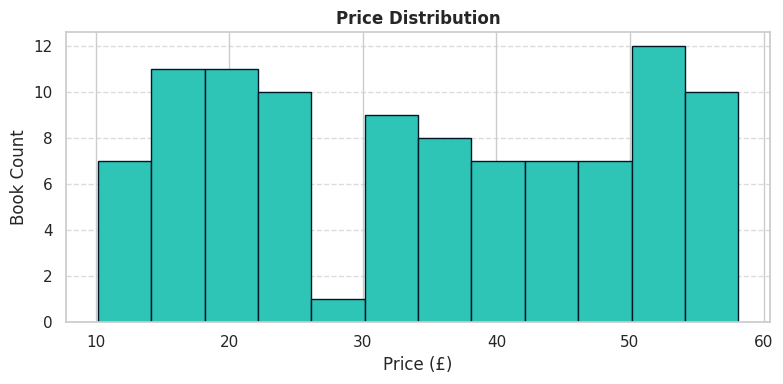

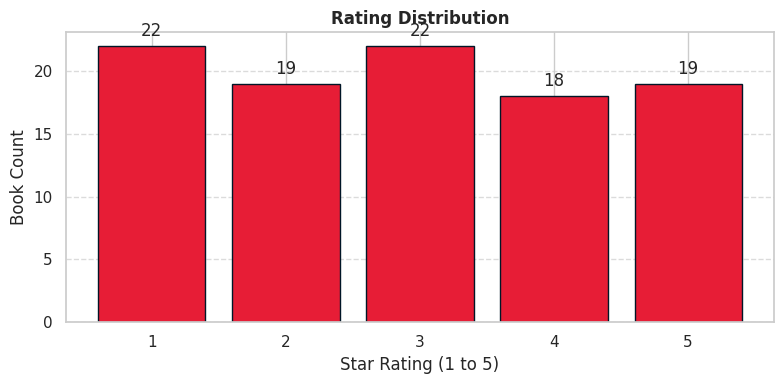

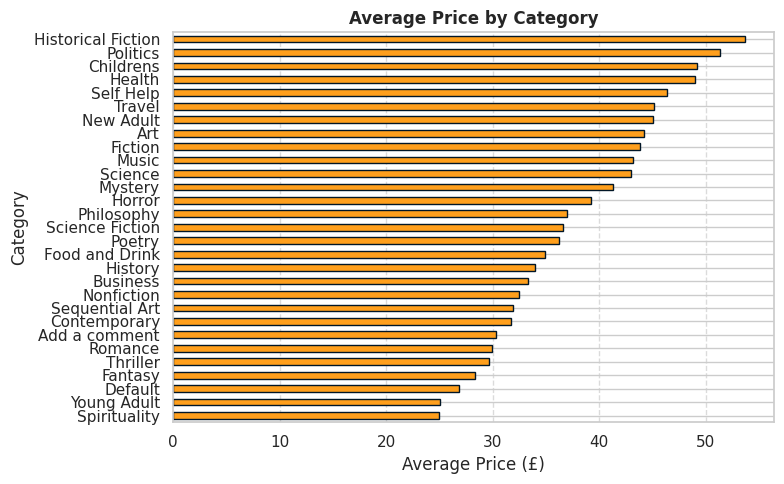

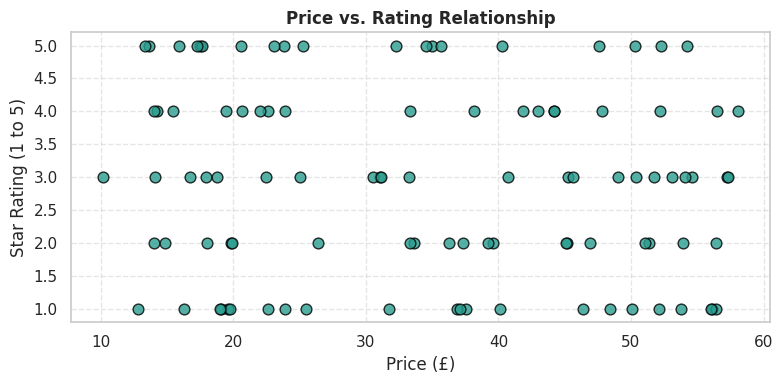

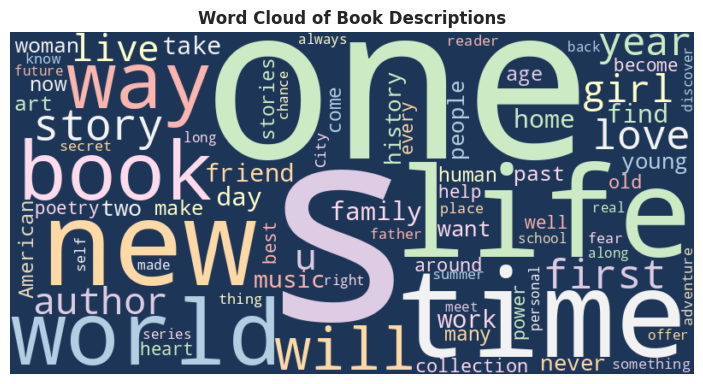


--- Summary Statistics ---
       price_numeric  rating_num  stock_count
count         100.00      100.00       100.00
mean           34.56        2.93        17.18
std            14.64        1.42         1.48
min            10.16        1.00        16.00
25%            19.90        2.00        16.00
50%            34.78        3.00        16.00
75%            47.97        4.00        19.00
max            58.11        5.00        22.00

--- Category Patterns ---
category
Sequential Art        14
Nonfiction            12
Default                9
Poetry                 7
Add a comment          5
Food and Drink         5
Fiction                5
History                4
Fantasy                4
Young Adult            4
Mystery                3
Thriller               3
Music                  3
Childrens              3
Science Fiction        2
Romance                2
Philosophy             2
Spirituality           2
Travel                 1
Politics               1
Business              

In [24]:
import matplotlib.pyplot as plt
import pandas as pd
from wordcloud import WordCloud

# Load clean data from Task 1
df = pd.read_csv("books_cleaned.csv")


# --- PLOT 1: PRICE DISTRIBUTION ---
plt.figure(figsize=(8, 4))
plt.hist(df["price_numeric"], bins=12, color="#2ec4b6", edgecolor="#011627")
plt.title("Price Distribution", fontsize=12, fontweight="bold")
plt.xlabel("Price (£)")
plt.ylabel("Book Count")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


# --- PLOT 2: RATING DISTRIBUTION ---
plt.figure(figsize=(8, 4))
rating_counts = df["rating_num"].value_counts().sort_index()
bars = plt.bar(
    rating_counts.index,
    rating_counts.values,
    color="#e71d36",
    edgecolor="#011627",
)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 0.5,
        int(yval),
        ha="center",
        va="bottom",
    )

plt.title("Rating Distribution", fontsize=12, fontweight="bold")
plt.xlabel("Star Rating (1 to 5)")
plt.ylabel("Book Count")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


# --- PLOT 3: AVERAGE PRICE BY CATEGORY ---
plt.figure(figsize=(8, 5))
avg_cat_price = df.groupby("category")["price_numeric"].mean().sort_values()
avg_cat_price.plot(kind="barh", color="#ff9f1c", edgecolor="#011627")
plt.title("Average Price by Category", fontsize=12, fontweight="bold")
plt.xlabel("Average Price (£)")
plt.ylabel("Category")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


# --- PLOT 4: PRICE VS RATING RELATIONSHIP ---
plt.figure(figsize=(8, 4))
plt.scatter(
    df["price_numeric"],
    df["rating_num"],
    color="#2a9d8f",
    edgecolor="black",
    s=60,
    alpha=0.8,
)
plt.title("Price vs. Rating Relationship", fontsize=12, fontweight="bold")
plt.xlabel("Price (£)")
plt.ylabel("Star Rating (1 to 5)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


# --- WORD CLOUD ---
text = " ".join(df["description"].dropna())
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="#1d3557",
    colormap="Pastel1",
    max_words=80,
).generate(text)

plt.figure(figsize=(8, 4))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Book Descriptions", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


# --- REQUIRED ANALYSIS OUTPUTS ONLY ---
print("\n--- Summary Statistics ---")
print(df[["price_numeric", "rating_num", "stock_count"]].describe().round(2))

print("\n--- Category Patterns ---")
print(df["category"].value_counts())

print("\n--- Highly Rated Books (5 Stars) ---")
print(
    df[df["rating_num"] == 5][["title", "category", "price_numeric"]].to_string(
        index=False
    )
)

print("\n--- Stock Patterns ---")
print(df["stock_count"].value_counts())

print("\n--- Missing Values Check ---")
print(df.isnull().sum())

Task 4 - Insights and Interpretation

● Write 5-7 clear observations supported by numerical results or plots.

● Explain whether price appears related to rating, which categories are most represented or expensive,
and which books provide the best value.

● Conclude with a brief discussion of the limitations of the scraped dataset and the analysis.

Key Observations:

1.Price Range: Book prices in the scraped dataset range from approximately £10 to £60, showing a fairly even spread without extreme pricing outliers.

2.Category Representation: Genres like Travel, Sequential Art, and Fiction are among the most frequently listed categories on the site.

3.Most Expensive Categories: Categories like Travel and Science Fiction tend to have a higher average price compared to general fiction.

4.Price vs. Rating Relationship: Looking at the scatter plot, there is no strong link between price and rating. High-rated 5-star books exist at both cheap (£15) and expensive (£50+) price points.

5.Best Value Books: Books with a high rating and low price yield the highest value_score (e.g., 5-star books priced under £20 give the best value for money).

6.Stock Pattern: Stock levels are relatively uniform across most books (around 19 items available per title), meaning inventory is balanced.


Price vs. Rating Relationship:

No, price is not related to rating. The scatter plot shows 5-star books at both cheap (£15) and expensive (£50+) price points, meaning higher price does not guarantee a higher rating.

Most Represented & Most Expensive Categories:

Most Represented: Travel and Sequential Art(they have the highest total book count).

Most Expensive:Travel and Science Fiction (they have the highest average price per book).


Best Value Books:
Books with a 5-star rating and a low price(under £20) provide the best value, as they give the highest `value_score` ($\text{Rating} / \text{Price}$).



Dataset & Analysis Limitations

Small Sample Size: We scraped a sample of 100 books across 5 pages out of thousands listed on the site.

No Real Customer Reviews: The website only provided book summary descriptions, so we used description text for the Word Cloud instead of actual customer feedback.

Single Point in Time: Data is a static snapshot; real-world prices, stock counts, and ratings change dynamically over time.